# Fresnel propagation verification using `optics_simulator.fresnel`

This notebook is a repository-ready version of the earlier standalone Fresnel sanity-check notebook.

The important change is that the propagation functions are **not redefined here**.  The notebook imports and tests the implementation in:

```python
from optics_simulator import fresnel
```

The notebook checks:

- plane-wave propagation;
- tilted-plane-wave phase response;
- Gaussian beam width evolution;
- fixed-grid energy conservation;
- one-step Fresnel output sampling;
- one-step Fresnel energy conservation;
- angular-spectrum round-trip propagation;
- angular-spectrum vs Fresnel transfer-function agreement;
- circular-aperture Airy first-null scaling;
- lens focal-plane scaling;
- thin-lens + one-step Fresnel equivalence to the direct focal-plane transform.

Run from the repository root so that `optics_simulator` is importable.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.special import j1
except ImportError as exc:
    raise ImportError("This notebook needs scipy. Install with: pip install scipy") from exc

# Make the notebook robust when launched from notebooks/ or examples/.
cwd = Path.cwd()
candidate_roots = [
    cwd,
    cwd.parent,
    cwd.parent.parent,
]
for root in candidate_roots:
    if (root / "optics_simulator").exists():
        sys.path.insert(0, str(root))
        REPO_ROOT = root
        break
else:
    REPO_ROOT = cwd

from optics_simulator import fresnel

DO_ASSERTS = True
np.set_printoptions(precision=4, suppress=True)

print("Repository root guess:", REPO_ROOT)
print("Imported fresnel module from:", Path(fresnel.__file__).resolve())


Repository root guess: /home/bbarrer/Documents/ULTIMATE/repositories/mq_glao_testbench_sim
Imported fresnel module from: /home/bbarrer/Documents/ULTIMATE/repositories/mq_glao_testbench_sim/optics_simulator/fresnel.py


## Helper functions

In [2]:
def require_function(name: str):
    fn = getattr(fresnel, name, None)
    if fn is None:
        raise AttributeError(f"optics_simulator.fresnel is missing required function: {name}")
    return fn


make_coordinate_grid = require_function("make_coordinate_grid")
fresnel_tf = require_function("fresnel_transfer_function_propagate")
angular_spectrum = require_function("angular_spectrum_propagate")
fresnel_one_step = require_function("fresnel_one_step_propagate")
lens_focal_plane_field = require_function("lens_focal_plane_field")
apply_thin_lens = require_function("apply_thin_lens")
circular_aperture = require_function("circular_aperture")
energy = require_function("energy")
relative_l2_error = require_function("relative_l2_error")


def check_less(name, value, threshold):
    status = "PASS" if value < threshold else "FAIL"
    print(f"{status:4s} | {name:55s} value={value:.6g}, threshold={threshold:.6g}")
    if DO_ASSERTS:
        assert value < threshold, f"{name}: value={value}, threshold={threshold}"


def check_close(name, value, target, rtol=1e-6, atol=0.0):
    err = abs(value - target)
    allowed = atol + rtol * abs(target)
    status = "PASS" if err <= allowed else "FAIL"
    print(
        f"{status:4s} | {name:55s} "
        f"value={value:.6g}, target={target:.6g}, err={err:.3g}, allowed={allowed:.3g}"
    )
    if DO_ASSERTS:
        assert err <= allowed, f"{name}: value={value}, target={target}, err={err}, allowed={allowed}"


def normalize_peak(arr):
    arr = np.asarray(arr, dtype=float)
    peak = np.nanmax(arr)
    return arr / peak if peak > 0 else arr


def gaussian_beam_width_analytic(w0, wavelength, z):
    zR = np.pi * w0**2 / wavelength
    return w0 * np.sqrt(1.0 + (z / zR) ** 2)


def estimate_gaussian_intensity_width(I, X, Y):
    """
    Estimate Gaussian field-amplitude radius w from intensity.

    If field amplitude is exp(-r^2/w^2), intensity is exp(-2r^2/w^2),
    so var(x) = w^2 / 4.
    """
    I = np.maximum(np.asarray(I, dtype=float), 0.0)
    total = np.sum(I)
    if total <= 0:
        return np.nan, np.nan, np.nan

    x0 = np.sum(X * I) / total
    y0 = np.sum(Y * I) / total
    varx = np.sum((X - x0) ** 2 * I) / total
    vary = np.sum((Y - y0) ** 2 * I) / total

    wx = 2.0 * np.sqrt(varx)
    wy = 2.0 * np.sqrt(vary)
    return float(wx), float(wy), float(0.5 * (wx + wy))


def radial_profile(image, dx, centre=None, nbins=600):
    image = np.asarray(image, dtype=float)
    ny, nx = image.shape
    yy, xx = np.indices(image.shape)

    if centre is None:
        yc, xc = np.unravel_index(np.nanargmax(image), image.shape)
    else:
        xc, yc = centre

    r = np.sqrt((xx - xc) ** 2 + (yy - yc) ** 2) * dx
    r_max = np.nanmax(r)
    bins = np.linspace(0.0, r_max, nbins + 1)
    r_mid = 0.5 * (bins[:-1] + bins[1:])
    prof = np.full(nbins, np.nan)

    for i in range(nbins):
        m = (r >= bins[i]) & (r < bins[i + 1])
        if np.any(m):
            prof[i] = np.nanmean(image[m])

    return r_mid, prof


def estimate_first_airy_minimum_radius(intensity, dx_focal, expected_radius):
    r, prof = radial_profile(intensity, dx=dx_focal, nbins=1000)
    prof = normalize_peak(prof)

    search = (
        (r > 0.55 * expected_radius)
        & (r < 1.45 * expected_radius)
        & np.isfinite(prof)
    )
    if not np.any(search):
        raise RuntimeError("No radial samples in Airy-minimum search region.")

    r_search = r[search]
    p_search = prof[search]

    return float(r_search[np.nanargmin(p_search)])


# Test 1 — Plane wave propagation

In [3]:
wavelength = 1.0e-6
N = 256
dx = 8.0e-6
z = 0.05

U0 = np.ones((N, N), dtype=complex)

Uz_tf = fresnel_tf(
    U0,
    wavelength=wavelength,
    dx=dx,
    z=z,
    include_global_phase=True,
)

Uz_as = angular_spectrum(
    U0,
    wavelength=wavelength,
    dx=dx,
    z=z,
    include_global_phase=True,
)

for label, Uz in [("Fresnel TF", Uz_tf), ("Angular spectrum", Uz_as)]:
    amp_error = np.max(np.abs(np.abs(Uz) - 1.0))
    phase0 = np.angle(Uz[N // 2, N // 2])
    phase_std = np.std(np.angle(Uz * np.exp(-1j * phase0)))

    check_less(f"{label}: plane-wave amplitude remains unity", amp_error, 1e-12)
    check_less(f"{label}: plane-wave phase is spatially constant", phase_std, 1e-12)


PASS | Fresnel TF: plane-wave amplitude remains unity          value=0, threshold=1e-12
PASS | Fresnel TF: plane-wave phase is spatially constant      value=0, threshold=1e-12
PASS | Angular spectrum: plane-wave amplitude remains unity    value=0, threshold=1e-12
PASS | Angular spectrum: plane-wave phase is spatially constant value=0, threshold=1e-12


# Test 2 — Tilted plane wave phase response

In [4]:
wavelength = 633e-9
N = 256
dx = 8e-6
z = 0.03

X, Y = make_coordinate_grid((N, N), dx)

# Choose frequencies exactly on FFT bins.
fx0 = 5.0 / (N * dx)
fy0 = -3.0 / (N * dx)

U0 = np.exp(2j * np.pi * (fx0 * X + fy0 * Y))

Uz = fresnel_tf(
    U0,
    wavelength=wavelength,
    dx=dx,
    z=z,
    include_global_phase=False,
)

ratio = Uz / U0
ratio_mean = np.mean(ratio)
expected = np.exp(-1j * np.pi * wavelength * z * (fx0**2 + fy0**2))

amp_std = np.std(np.abs(ratio))
phase_err = abs(np.angle(ratio_mean / expected))

check_less("tilted plane wave ratio has constant amplitude", amp_std, 1e-12)
check_less("tilted plane wave Fresnel phase factor", phase_err, 1e-10)


PASS | tilted plane wave ratio has constant amplitude          value=6.34167e-16, threshold=1e-12
PASS | tilted plane wave Fresnel phase factor                  value=4.91453e-17, threshold=1e-10


# Test 3 — Gaussian beam propagation width

In [5]:
wavelength = 633e-9
N = 512
dx = 8e-6
z = 0.15
w0 = 0.35e-3

X, Y = make_coordinate_grid((N, N), dx)
R2 = X**2 + Y**2

U0 = np.exp(-R2 / w0**2)

Uz = fresnel_tf(
    U0,
    wavelength=wavelength,
    dx=dx,
    z=z,
    include_global_phase=False,
)

I = np.abs(Uz)**2
wx, wy, w_meas = estimate_gaussian_intensity_width(I, X, Y)
w_expected = gaussian_beam_width_analytic(w0, wavelength, z)

rel_err = abs(w_meas - w_expected) / w_expected

print("Measured wx, wy, w_mean [um]:", wx * 1e6, wy * 1e6, w_meas * 1e6)
print("Expected w(z) [um]:", w_expected * 1e6)
check_less("Gaussian propagated width relative error", rel_err, 0.02)


Measured wx, wy, w_mean [um]: 360.49525326695175 360.49525326695175 360.49525326695175
Expected w(z) [um]: 360.4952532669518
PASS | Gaussian propagated width relative error                value=1.50377e-16, threshold=0.02


# Test 4 — Fixed-grid energy conservation

In [8]:
wavelength = 633e-9
N = 256
dx = 10e-6
z = 0.12

X, Y = make_coordinate_grid((N, N), dx)
U0 = (1+0*1J) * np.exp(-(X**2 + Y**2) / (0.35e-3)**2)
U0 *= np.exp(1j * 0.4 * np.sin(2 * np.pi * X / 0.3e-3))

E0 = energy(U0, dx)

for label, propagator in [
    ("Fresnel TF", fresnel_tf),
    ("Angular spectrum", angular_spectrum),
]:
    Uz = propagator(
        U0,
        wavelength=wavelength,
        dx=dx,
        z=z,
        include_global_phase=False,
    )
    Ez = energy(Uz, dx)
    rel_err = abs(Ez - E0) / E0
    check_less(f"{label}: energy conservation", rel_err, 1e-12)


PASS | Fresnel TF: energy conservation                         value=0, threshold=1e-12
PASS | Angular spectrum: energy conservation                   value=0, threshold=1e-12


# Test 5 — One-step Fresnel output sampling and energy

In [9]:
wavelength = 633e-9
N = 256
dx = 8e-6
z = 0.2

X, Y = make_coordinate_grid((N, N), dx)
U0 = np.exp(-(X**2 + Y**2) / (0.25e-3)**2)

U2, dx2, dy2 = fresnel_one_step(
    U0,
    wavelength=wavelength,
    dx=dx,
    z=z,
    include_global_phase=False,
)

expected_dx2 = wavelength * abs(z) / (N * dx)

check_close("one-step Fresnel dx_out", dx2, expected_dx2, rtol=1e-14)
check_close("one-step Fresnel dy_out", dy2, expected_dx2, rtol=1e-14)

E0 = energy(U0, dx)
E2 = energy(U2, dx2, dy2)
rel_err = abs(E2 - E0) / E0
check_less("one-step Fresnel energy conservation", rel_err, 1e-12)


PASS | one-step Fresnel dx_out                                 value=6.18164e-05, target=6.18164e-05, err=0, allowed=6.18e-19
PASS | one-step Fresnel dy_out                                 value=6.18164e-05, target=6.18164e-05, err=0, allowed=6.18e-19
PASS | one-step Fresnel energy conservation                    value=0, threshold=1e-12


# Test 6 — Angular-spectrum round trip

In [10]:
wavelength = 633e-9
N = 256
dx = 10e-6
z = 0.15

X, Y = make_coordinate_grid((N, N), dx)

U0 = (
    np.exp(-(X**2 + Y**2) / (0.35e-3)**2)
    * np.exp(1j * 0.5 * np.sin(2.0 * np.pi * X / 0.28e-3))
)

U1 = angular_spectrum(
    U0,
    wavelength=wavelength,
    dx=dx,
    z=z,
    include_global_phase=False,
)

U2 = angular_spectrum(
    U1,
    wavelength=wavelength,
    dx=dx,
    z=-z,
    include_global_phase=False,
)

err = relative_l2_error(U0, U2, remove_scale=True)
check_less("angular-spectrum forward/backward round trip", err, 1e-12)


PASS | angular-spectrum forward/backward round trip            value=4.97366e-16, threshold=1e-12


# Test 7 — Angular spectrum vs Fresnel transfer function

In [11]:
wavelength = 633e-9
N = 256
dx = 8e-6
z = 0.03

X, Y = make_coordinate_grid((N, N), dx)
U0 = np.exp(-(X**2 + Y**2) / (0.28e-3)**2)

U_as = angular_spectrum(
    U0,
    wavelength=wavelength,
    dx=dx,
    z=z,
    include_global_phase=False,
)

U_tf = fresnel_tf(
    U0,
    wavelength=wavelength,
    dx=dx,
    z=z,
    include_global_phase=False,
)

err = relative_l2_error(U_as, U_tf, remove_scale=True)
check_less("angular spectrum agrees with Fresnel TF in paraxial regime", err, 1e-3)


PASS | angular spectrum agrees with Fresnel TF in paraxial regime value=1.12174e-08, threshold=0.001


# Test 8 — Circular aperture Airy first-null scaling

In [12]:
wavelength = 633e-9
N = 512
pad_to = 2048
dx = 10e-6
D = 1.0e-3
f = 0.25

pupil = circular_aperture(
    shape=(N, N),
    dx=dx,
    radius=0.5 * D,
).astype(complex)

pad = pad_to - N
pupil_pad = np.pad(
    pupil,
    ((pad // 2, pad - pad // 2), (pad // 2, pad - pad // 2)),
    mode="constant",
)

U_focus, dx_foc, dy_foc = lens_focal_plane_field(
    pupil_pad,
    wavelength=wavelength,
    dx=dx,
    focal_length=f,
    include_global_phase=False,
)

I_focus = normalize_peak(np.abs(U_focus)**2)

expected_first_null = 1.22 * wavelength * f / D
measured_first_null = estimate_first_airy_minimum_radius(
    I_focus,
    dx_focal=dx_foc,
    expected_radius=expected_first_null,
)

rel_err = abs(measured_first_null - expected_first_null) / expected_first_null

print("dx_focal [um]:", dx_foc * 1e6)
print("expected first null [um]:", expected_first_null * 1e6)
print("measured first null [um]:", measured_first_null * 1e6)
print("pixels per Airy radius:", expected_first_null / dx_foc)

check_less("Airy first-null relative error", rel_err, 0.06)


dx_focal [um]: 7.727050781249999
expected first null [um]: 193.065
measured first null [um]: 195.8243842148495
pixels per Airy radius: 24.9856
PASS | Airy first-null relative error                          value=0.0142925, threshold=0.06


# Test 9 — Thin-lens + one-step Fresnel equals direct focal-plane transform

In [13]:
wavelength = 633e-9
N = 512
pad_to = 1024
dx = 10e-6
D = 1.0e-3
f = 0.25

pupil = circular_aperture(
    shape=(N, N),
    dx=dx,
    radius=0.5 * D,
).astype(complex)

pad = pad_to - N
pupil_pad = np.pad(
    pupil,
    ((pad // 2, pad - pad // 2), (pad // 2, pad - pad // 2)),
    mode="constant",
)

U_lens = apply_thin_lens(
    pupil_pad,
    wavelength=wavelength,
    dx=dx,
    focal_length=f,
)

U_focus_one_step, dx1, dy1 = fresnel_one_step(
    U_lens,
    wavelength=wavelength,
    dx=dx,
    z=f,
    include_global_phase=False,
)

U_focus_direct, dx2, dy2 = lens_focal_plane_field(
    pupil_pad,
    wavelength=wavelength,
    dx=dx,
    focal_length=f,
    include_global_phase=False,
)

check_close("thin-lens one-step dx matches direct focal dx", dx1, dx2, rtol=1e-14)
check_close("thin-lens one-step dy matches direct focal dy", dy1, dy2, rtol=1e-14)

I1 = normalize_peak(np.abs(U_focus_one_step)**2)
I2 = normalize_peak(np.abs(U_focus_direct)**2)

err = np.linalg.norm(I1 - I2) / np.linalg.norm(I2)
check_less("thin-lens one-step intensity equals direct focal-plane intensity", err, 1e-10)


PASS | thin-lens one-step dx matches direct focal dx           value=1.54541e-05, target=1.54541e-05, err=0, allowed=1.55e-19
PASS | thin-lens one-step dy matches direct focal dy           value=1.54541e-05, target=1.54541e-05, err=0, allowed=1.55e-19
PASS | thin-lens one-step intensity equals direct focal-plane intensity value=2.51804e-16, threshold=1e-10


# Test 10 — Diagnostic plots

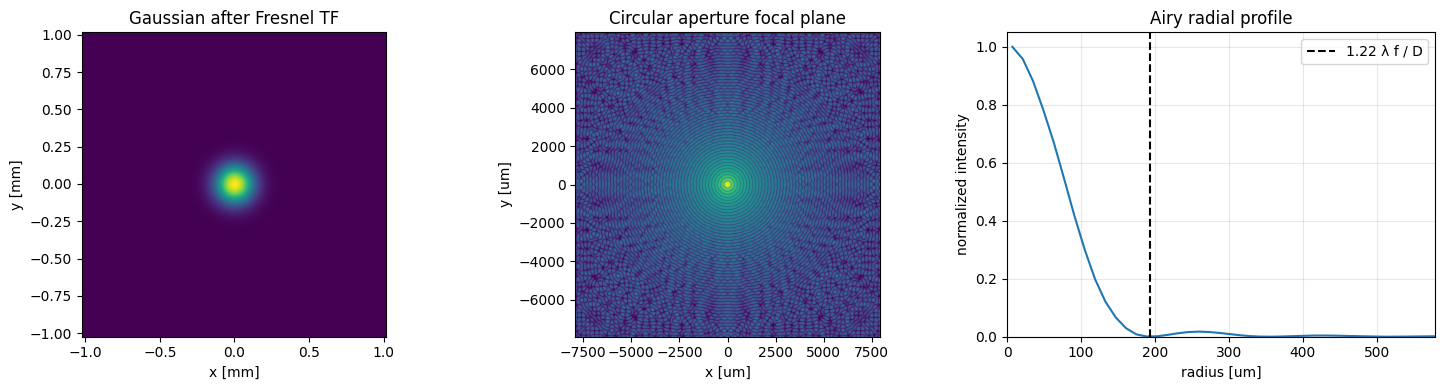

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gaussian propagation plot
axes[0].imshow(
    normalize_peak(I),
    origin="lower",
    extent=[
        X.min() * 1e3,
        X.max() * 1e3,
        Y.min() * 1e3,
        Y.max() * 1e3,
    ],
)
axes[0].set_title("Gaussian after Fresnel TF")
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("y [mm]")

# Airy plot
extent_um = [
    -0.5 * I_focus.shape[1] * dx_foc * 1e6,
    +0.5 * I_focus.shape[1] * dx_foc * 1e6,
    -0.5 * I_focus.shape[0] * dy_foc * 1e6,
    +0.5 * I_focus.shape[0] * dy_foc * 1e6,
]
axes[1].imshow(
    np.log10(np.maximum(I_focus, 1e-8)),
    origin="lower",
    extent=extent_um,
)
axes[1].set_title("Circular aperture focal plane")
axes[1].set_xlabel("x [um]")
axes[1].set_ylabel("y [um]")

# Radial profile
r, prof = radial_profile(I_focus, dx=dx_foc, nbins=800)
axes[2].plot(r * 1e6, normalize_peak(prof))
axes[2].axvline(expected_first_null * 1e6, color="k", ls="--", label="1.22 λ f / D")
axes[2].set_xlim(0, 3.0 * expected_first_null * 1e6)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_title("Airy radial profile")
axes[2].set_xlabel("radius [um]")
axes[2].set_ylabel("normalized intensity")

plt.tight_layout()
plt.show()


## Summary

If every check above prints `PASS`, the repository `fresnel.py` implementation has passed the same style of sanity checks as the original standalone notebook, but now using the actual module functions.